
# MC Dropout for Uncertainty Estimation on MNIST

Reimplementation and study of:

> **Yarin Gal and Zoubin Ghahramani.** *Dropout as a Bayesian Approximation: Representing Model Uncertainty in Deep Learning.* ICML 2016. [arXiv:1506.02142](https://arxiv.org/abs/1506.02142)

This notebook is **self-contained**: it imports the reusable `src/mc_dropout` package, trains the model, runs Monte Carlo (MC) dropout, and produces every figure referenced in the report. The CLI scripts in `experiments/` produce the *same* artefacts non-interactively.

**What you will see, in order:**
1. Train a small CNN with dropout on MNIST.
2. Compare standard (dropout off) and MC Dropout (T stochastic passes) predictions.
3. Three uncertainty measures: predictive entropy, predictive variance, and mutual information (BALD).
4. Reproduce the paper's **rotating-digit** signature figure (digit "1", T=100), with both the mean-+/-1-std view and a per-pass scatter that mirrors Fig. 4 of the paper.
5. **Extension** (not in the paper): out-of-distribution detection on FashionMNIST, scored by AUROC.
6. Convergence of the MC estimate with the number of samples T.
7. Robustness across random seeds (loaded from the CLI experiment).
8. UCI regression reproduction of one Table-1 row (Concrete Strength), loaded from the CLI experiment.



## 0. Setup

Run all cells from the **repository root** (the folder containing `src/`, `experiments/`, `figures/`, `results/`).

A GPU is *not* required; everything below runs in a couple of minutes on CPU.


In [1]:

import os, sys, math, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

assert os.path.isdir('src') and os.path.isdir('experiments'), \
    'Please run this notebook from the repository root.'
if 'src' not in sys.path:
    sys.path.insert(0, 'src')
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

from mc_dropout import (
    set_seed, get_device, MCDropoutCNN,
    get_mnist_loaders, get_raw_test_dataset, get_ood_loader, normalise,
    enable_dropout, standard_predict, mc_forward, mc_forward_batch,
    predictive_mean, predictive_entropy, mutual_information, predictive_variance,
    negative_log_likelihood, summarise,
    train_model, save_checkpoint,
)
SEED = 42
set_seed(SEED)
device = get_device('auto')
print('Using device:', device)


Using device: cpu



## 1. Data and model

We use MNIST (60k/10k train/test, 28x28 grayscale digits) with the standard normalisation (mean 0.1307, std 0.3081). The model is a small convolutional network with two convolutional blocks, followed by a fully-connected head; **dropout is placed before *both* fully-connected layers** so it is active at test time when we evaluate with MC Dropout. The dropout rate is 0.5 and we use L2 regularisation 1e-4, following the paper's MNIST recipe.

Architecture: `Conv(1->32) -> ReLU -> Pool -> Conv(32->64) -> ReLU -> Pool -> Flatten -> Dropout -> FC(3136->128) -> ReLU -> Dropout -> FC(128->10)`. About 422k parameters.


In [2]:

train_loader, test_loader = get_mnist_loaders(batch_size=128, data_dir='./data')
print('Train batches:', len(train_loader), 'Test batches:', len(test_loader))

model = MCDropoutCNN(p=0.5).to(device)
print(model)
print('Trainable parameters:', sum(p.numel() for p in model.parameters()))


Train batches: 469 Test batches: 79
MCDropoutCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (drop2): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Trainable parameters: 421642



## 2. Train (5 epochs, Adam, weight decay 1e-4)

Five epochs is enough on MNIST to get ~99% train accuracy with this model. The paper itself trains LeNet for ~10^6 iterations on MNIST, which produces a similar test accuracy; our experiments below show that the qualitative MC-Dropout findings reproduce with the smaller training budget.


Epoch 1/5:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: loss=0.2822  acc=0.9106


Epoch 2/5:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: loss=0.1040  acc=0.9681


Epoch 3/5:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 3: loss=0.0802  acc=0.9756


Epoch 4/5:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 4: loss=0.0707  acc=0.9785


Epoch 5/5:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 5: loss=0.0654  acc=0.9798


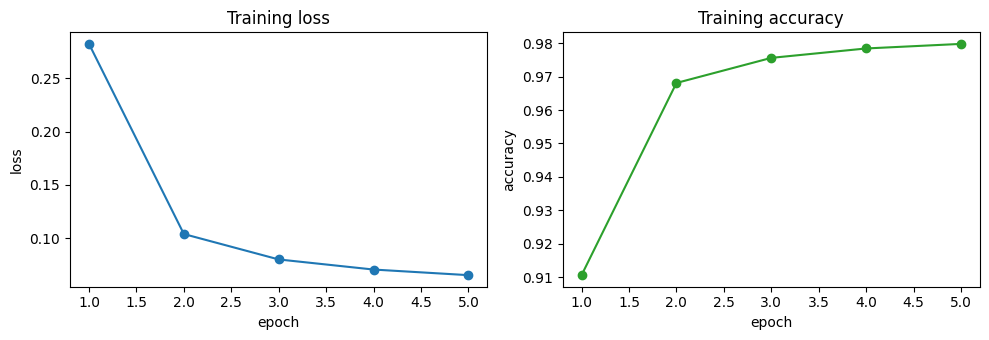

In [3]:

history = train_model(
    model, train_loader, epochs=5, lr=1e-3,
    device=device, weight_decay=1e-4, verbose=True,
)
save_checkpoint(model, 'results/model.pt',
                meta={'dropout': 0.5, 'epochs': 5, 'seed': SEED})

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(range(1, 6), history['train_loss'], marker='o')
ax[0].set_title('Training loss');     ax[0].set_xlabel('epoch');  ax[0].set_ylabel('loss')
ax[1].plot(range(1, 6), history['train_acc'],  marker='o', color='tab:green')
ax[1].set_title('Training accuracy'); ax[1].set_xlabel('epoch');  ax[1].set_ylabel('accuracy')
fig.tight_layout()
fig.savefig('figures/training_curves.png', dpi=150)
plt.show()



## 3. Standard vs MC Dropout predictions

The paper's central practical claim: keep dropout *on* at test time, do `T` stochastic forward passes, and average the softmax outputs (eq. (6) of the paper). The standard-mode and MC-mode accuracies should be **essentially identical** -- the value of MC Dropout is the *uncertainty signal* it adds, not raw accuracy.


In [4]:

std_probs, labels = standard_predict(model, test_loader, device)
std_acc = (std_probs.argmax(1) == labels).float().mean().item()

T = 30
probs_T, labels = mc_forward(model, test_loader, device, T=T)   # (T, N, 10)
out = summarise(probs_T, labels)
preds, entropy, variance, mi = out['preds'], out['entropy'], out['variance'], out['mutual_information']
mc_acc = (preds == labels).float().mean().item()

print(f'Standard test accuracy:        {std_acc:.4f}')
print(f'MC Dropout accuracy (T={T}): {mc_acc:.4f}')


Standard test accuracy:        0.9897
MC Dropout accuracy (T=30): 0.9899



## 4. Uncertainty signals: entropy, variance, mutual information

For each test image, after `T` stochastic passes we get a tensor of softmax outputs of shape `(T, 10)`. From it we compute:

- **Predictive entropy** `H[ E_t[p_t] ]` -- total uncertainty (epistemic + aleatoric).
- **Predictive variance** of the softmax outputs over the T passes, averaged across classes -- how much the model disagrees with itself.
- **Mutual information** `H[ E_t[p_t] ] - E_t[ H[p_t] ]` (a.k.a. BALD, Houlsby et al. 2011) -- the *epistemic* part: large when the individual passes are confident but disagree.

A useful diagnostic: **how do these signals differ between correct and wrong predictions?** If MC Dropout's uncertainty is meaningful, wrong predictions should sit at systematically higher entropy.


In [5]:

correct = (preds == labels)
wrong   = ~correct
n_wrong = int(wrong.sum())

ent_c, ent_w = entropy[correct].mean().item(), entropy[wrong].mean().item()
var_c, var_w = variance[correct].mean().item(), variance[wrong].mean().item()
mi_c,  mi_w  = mi[correct].mean().item(),       mi[wrong].mean().item()

summary = pd.DataFrame({
    'metric': ['Standard test accuracy', f'MC Dropout accuracy (T={T})',
               'Mean predictive entropy - correct', 'Mean predictive entropy - wrong',
               'Mean predictive variance - correct', 'Mean predictive variance - wrong',
               'Mean mutual information - correct', 'Mean mutual information - wrong',
               'Entropy ratio (wrong/correct)', '# wrong MC predictions'],
    'value': [f'{std_acc:.4f}', f'{mc_acc:.4f}',
              f'{ent_c:.4f}', f'{ent_w:.4f}',
              f'{var_c:.6f}', f'{var_w:.6f}',
              f'{mi_c:.4f}', f'{mi_w:.4f}',
              f'{(ent_w/ent_c):.2f}', f'{n_wrong} / {len(labels)}'],
})
summary.to_csv('results/summary.csv', index=False)
summary


,metric,value
0,Standard test accuracy,0.9897
1,MC Dropout accuracy (T=30),0.9899
2,Mean predictive entropy - correct,0.1001
3,Mean predictive entropy - wrong,0.9664
4,Mean predictive variance - correct,0.001301
5,Mean predictive variance - wrong,0.019137
6,Mean mutual information - correct,0.0388
7,Mean mutual information - wrong,0.3522
8,Entropy ratio (wrong/correct),9.66
9,# wrong MC predictions,101 / 10000


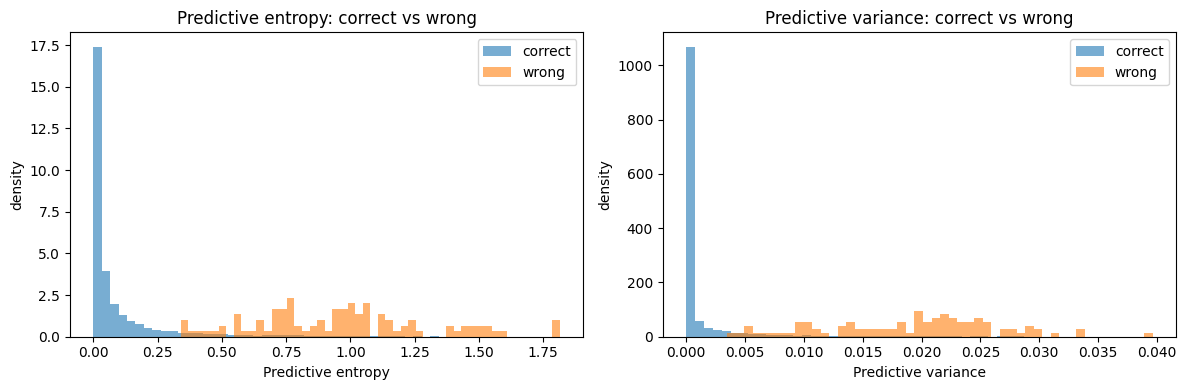

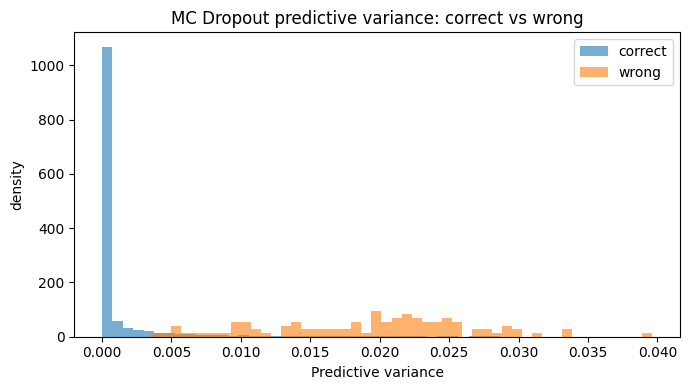

In [6]:

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, (name, vec) in zip(ax, [('Predictive entropy', entropy), ('Predictive variance', variance)]):
    a.hist(vec[correct].numpy(), bins=50, alpha=0.6, label='correct', density=True)
    a.hist(vec[wrong].numpy(),   bins=50, alpha=0.6, label='wrong',   density=True)
    a.set_xlabel(name); a.set_ylabel('density'); a.set_title(name + ': correct vs wrong')
    a.legend()
fig.tight_layout()
fig.savefig('figures/entropy_correct_vs_wrong.png', dpi=150)
# also save the right panel on its own (used in report)
fig2, axv = plt.subplots(figsize=(7, 4))
axv.hist(variance[correct].numpy(), bins=50, alpha=0.6, label='correct', density=True)
axv.hist(variance[wrong].numpy(),   bins=50, alpha=0.6, label='wrong',   density=True)
axv.set_xlabel('Predictive variance'); axv.set_ylabel('density')
axv.set_title('MC Dropout predictive variance: correct vs wrong'); axv.legend()
fig2.tight_layout()
fig2.savefig('figures/variance_correct_vs_wrong.png', dpi=150)
plt.show()



## 5. Most-confident vs most-uncertain test images

A direct qualitative check: the model's most-confident images should look like crisp, prototypical digits; the most-uncertain ones should be visually ambiguous.


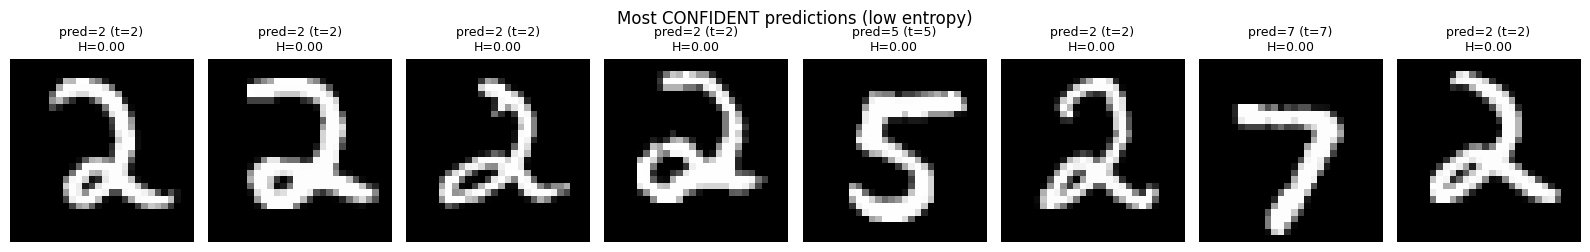

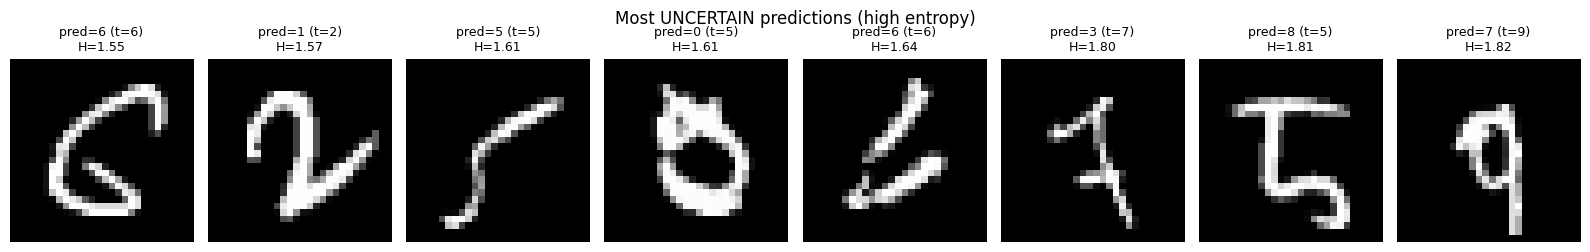

In [7]:

raw_set = get_raw_test_dataset(data_dir='./data')

def show_grid(indices, title, fname):
    n = len(indices)
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.6))
    if n == 1: axes = [axes]
    for ax, idx in zip(axes, indices):
        img, true = raw_set[idx]
        ax.imshow(img.squeeze().numpy(), cmap='gray')
        ax.set_title(f'pred={int(preds[idx])} (t={int(true)})\nH={entropy[idx]:.2f}', fontsize=9)
        ax.axis('off')
    fig.suptitle(title); fig.tight_layout()
    fig.savefig(fname, dpi=150)
    plt.show()

sorted_idx = torch.argsort(entropy)
show_grid(sorted_idx[:8].tolist(),  'Most CONFIDENT predictions (low entropy)',
          'figures/confident_examples.png')
show_grid(sorted_idx[-8:].tolist(), 'Most UNCERTAIN predictions (high entropy)',
          'figures/uncertain_examples.png')



## 6. The rotating-digit signature experiment (paper Fig. 4)

The most famous MC Dropout demonstration: take a single test digit, rotate it through a range of angles, and run `T=100` stochastic forward passes at each angle. At 0 degrees the model is confidently right; as the digit rotates into an ambiguous shape, the predictions across passes spread out and the predictive entropy spikes.

We mirror the paper by rotating a **"1"**, with T=100 passes. Two views are produced: the standard mean +/- 1 std summary, and a per-pass scatter that mirrors Fig. 4 (softmax inputs on top, softmax outputs on bottom).


Using test index 2 (true label 1 )


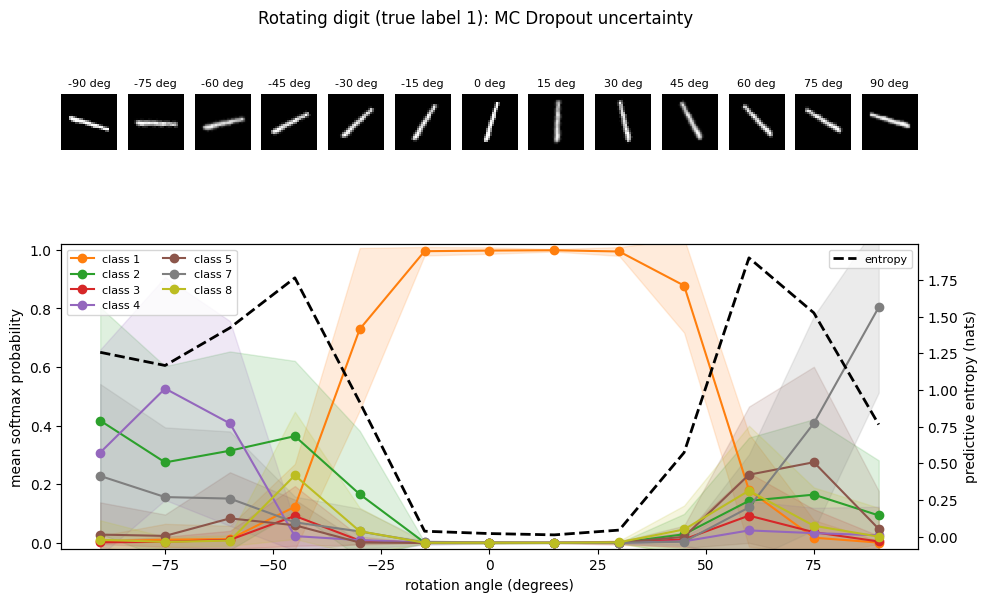

In [8]:

import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

# pick the first "1"
idx = next(i for i in range(len(raw_set)) if int(raw_set[i][1]) == 1)
raw_img, true_label = raw_set[idx]
print('Using test index', idx, '(true label', int(true_label), ')')

angles = list(range(-90, 91, 15))
T_rot = 100
model.eval(); enable_dropout(model)

n_ang, C = len(angles), 10
all_logits = np.zeros((n_ang, T_rot, C))
all_probs  = np.zeros((n_ang, T_rot, C))
disp_imgs  = []
with torch.no_grad():
    for i, ang in enumerate(angles):
        rotated_raw = TF.rotate(raw_img, ang, interpolation=InterpolationMode.BILINEAR, fill=0.0)
        disp_imgs.append(rotated_raw.squeeze().numpy())
        x = normalise(rotated_raw).unsqueeze(0).to(device)
        logits = torch.stack([model(x) for _ in range(T_rot)], dim=0).squeeze(1)  # (T, C)
        all_logits[i] = logits.cpu().numpy()
        all_probs[i]  = F.softmax(logits, dim=-1).cpu().numpy()

mean_p = all_probs.mean(axis=1)
std_p  = all_probs.std(axis=1)
ent    = -(mean_p * np.log(mean_p + 1e-12)).sum(axis=1)
selected = sorted(set([int(true_label)] + list(np.where(mean_p.max(axis=0) > 0.05)[0])))
cmap = plt.get_cmap('tab10')

# --- View A: mean +/- 1 std with entropy overlay
fig = plt.figure(figsize=(max(9, n_ang*0.85), 6.2))
gs = fig.add_gridspec(2, n_ang, height_ratios=[1, 3], hspace=0.35)
for i, ang in enumerate(angles):
    a = fig.add_subplot(gs[0, i]); a.imshow(disp_imgs[i], cmap='gray'); a.set_title(f'{ang} deg', fontsize=8); a.axis('off')
ax = fig.add_subplot(gs[1, :])
for c in selected:
    ax.plot(angles, mean_p[:, c], marker='o', color=cmap(c%10), label=f'class {c}')
    ax.fill_between(angles, mean_p[:, c]-std_p[:, c], mean_p[:, c]+std_p[:, c], color=cmap(c%10), alpha=0.15)
ax.set_xlabel('rotation angle (degrees)'); ax.set_ylabel('mean softmax probability'); ax.set_ylim(-.02, 1.02)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax2 = ax.twinx(); ax2.plot(angles, ent, 'k--', linewidth=2, label='entropy')
ax2.set_ylabel('predictive entropy (nats)'); ax2.legend(loc='upper right', fontsize=8)
fig.suptitle(f'Rotating digit (true label {int(true_label)}): MC Dropout uncertainty')
fig.savefig('figures/rotating_digit.png', dpi=150, bbox_inches='tight')
plt.show()


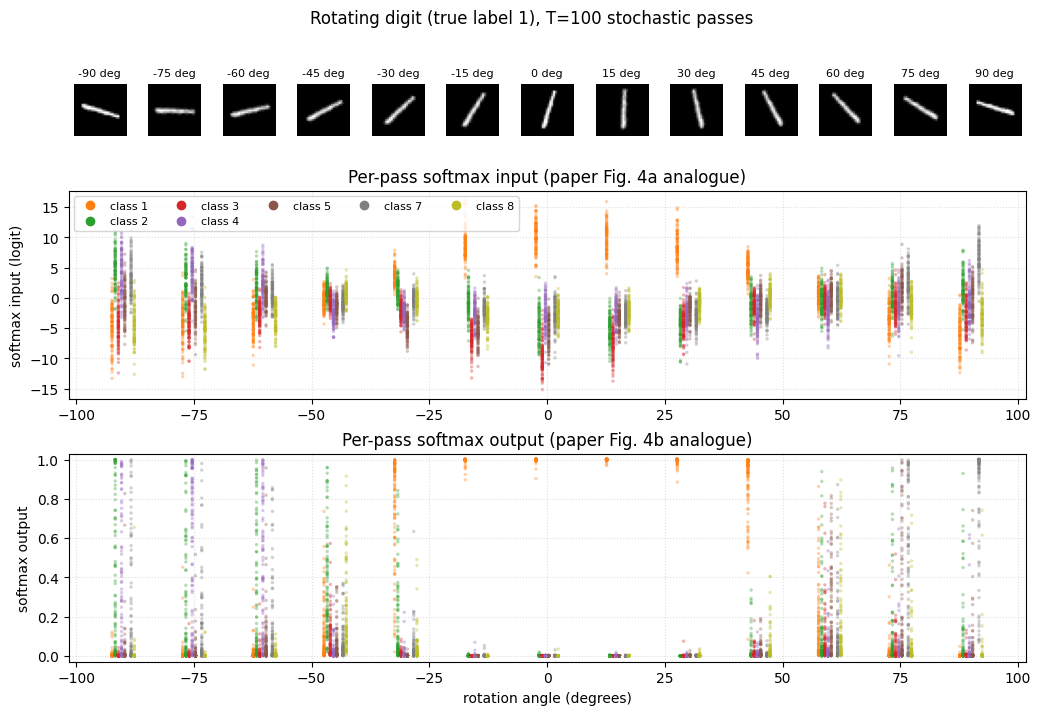

In [9]:

# --- View B: per-pass scatter (paper Fig. 4 mirror)
fig2 = plt.figure(figsize=(max(11, n_ang*0.95), 7.5))
gs2 = fig2.add_gridspec(3, n_ang, height_ratios=[1, 4, 4], hspace=0.35)
for i, ang in enumerate(angles):
    a = fig2.add_subplot(gs2[0, i]); a.imshow(disp_imgs[i], cmap='gray'); a.set_title(f'{ang} deg', fontsize=8); a.axis('off')
ax_in  = fig2.add_subplot(gs2[1, :])
ax_out = fig2.add_subplot(gs2[2, :], sharex=ax_in)
jitter = (angles[1]-angles[0]) * 0.045
for c in selected:
    color = cmap(c%10)
    for i, ang in enumerate(angles):
        jx = ang + (c - 4.5) * jitter
        xs = np.full(T_rot, jx)
        ax_in.scatter (xs, all_logits[i, :, c], s=6, alpha=0.35, color=color, edgecolors='none')
        ax_out.scatter(xs, all_probs[i, :, c],  s=6, alpha=0.35, color=color, edgecolors='none')
    ax_in.plot([], [], 'o', color=color, label=f'class {c}')
ax_in.set_ylabel('softmax input (logit)');  ax_in.set_title('Per-pass softmax input (paper Fig. 4a analogue)');
ax_in.legend(loc='upper left', fontsize=8, ncol=min(len(selected), 5)); ax_in.grid(True, ls=':', alpha=0.4)
ax_out.set_ylabel('softmax output');         ax_out.set_xlabel('rotation angle (degrees)')
ax_out.set_title('Per-pass softmax output (paper Fig. 4b analogue)'); ax_out.set_ylim(-0.03, 1.03)
ax_out.grid(True, ls=':', alpha=0.4)
fig2.suptitle(f'Rotating digit (true label {int(true_label)}), T={T_rot} stochastic passes')
fig2.savefig('figures/rotating_digit_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

pd.DataFrame({'angle': angles, 'entropy': ent,
              'top_class': mean_p.argmax(axis=1), 'top_prob': mean_p.max(axis=1)}
).to_csv('results/rotating_digit.csv', index=False)



## 7. Out-of-distribution detection on FashionMNIST (extension, *not* in the paper)

The paper studies uncertainty on *in-distribution* inputs. A natural follow-up: do MC Dropout's uncertainty signals also flag inputs the model was *never trained on*? We test the same network on FashionMNIST (same 28x28 grayscale shape, completely different content) and score the binary separation MNIST-vs-FashionMNIST with AUROC, using the predictive entropy as the OOD score.

This is *not* a reproduction of any result in Gal & Ghahramani (2016); we include it because it directly tests the downstream usefulness of the paper's uncertainty signal.


Mean entropy  | MNIST: 0.1083   FashionMNIST: 1.3775
AUROC (entropy):           0.9885
AUROC (mutual information):0.9594


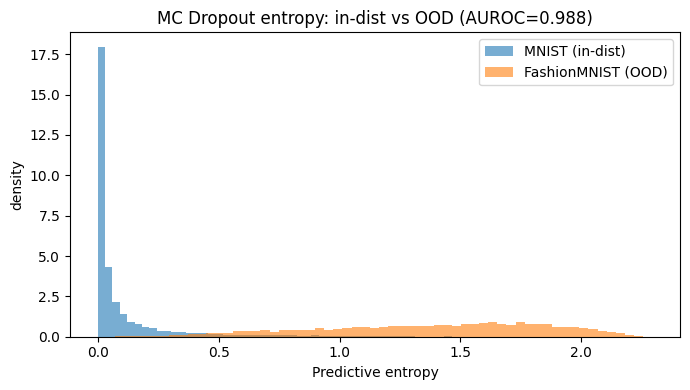

In [10]:

from sklearn.metrics import roc_auc_score
ood_loader = get_ood_loader(batch_size=128, data_dir='./data')

probs_T_in,  _ = mc_forward(model, test_loader, device, T=30)
probs_T_ood, _ = mc_forward(model, ood_loader,  device, T=30)
ent_in  = predictive_entropy(predictive_mean(probs_T_in )).numpy()
ent_ood = predictive_entropy(predictive_mean(probs_T_ood)).numpy()
mi_in   = mutual_information(probs_T_in ).numpy()
mi_ood  = mutual_information(probs_T_ood).numpy()

y_true = np.concatenate([np.zeros_like(ent_in), np.ones_like(ent_ood)])
auroc_ent = roc_auc_score(y_true, np.concatenate([ent_in,  ent_ood]))
auroc_mi  = roc_auc_score(y_true, np.concatenate([mi_in,   mi_ood ]))
print(f'Mean entropy  | MNIST: {ent_in.mean():.4f}   FashionMNIST: {ent_ood.mean():.4f}')
print(f'AUROC (entropy):           {auroc_ent:.4f}')
print(f'AUROC (mutual information):{auroc_mi:.4f}')

plt.figure(figsize=(7, 4))
plt.hist(ent_in,  bins=60, alpha=0.6, label='MNIST (in-dist)',      density=True)
plt.hist(ent_ood, bins=60, alpha=0.6, label='FashionMNIST (OOD)',   density=True)
plt.xlabel('Predictive entropy'); plt.ylabel('density')
plt.title(f'MC Dropout entropy: in-dist vs OOD (AUROC={auroc_ent:.3f})')
plt.legend(); plt.tight_layout()
plt.savefig('figures/ood_entropy_hist.png', dpi=150)
plt.show()

pd.DataFrame({
    'metric': ['Mean predictive entropy - MNIST (in-dist)',
               'Mean predictive entropy - FashionMNIST (OOD)',
               'Mean mutual information - MNIST (in-dist)',
               'Mean mutual information - FashionMNIST (OOD)',
               'OOD-detection AUROC (entropy)',
               'OOD-detection AUROC (mutual information)'],
    'value':  [f'{ent_in.mean():.4f}',  f'{ent_ood.mean():.4f}',
               f'{mi_in.mean():.4f}',   f'{mi_ood.mean():.4f}',
               f'{auroc_ent:.4f}',      f'{auroc_mi:.4f}'],
}).to_csv('results/ood_summary.csv', index=False)



## 8. How many MC samples T are needed?

The paper observes that T=10 already gives "a reasonable estimation to the predictive mean and uncertainty" while T=1000 is used for the visualisations. We sweep T from 1 to 100 and watch accuracy and the per-example negative log-likelihood (NLL) of the true class converge.


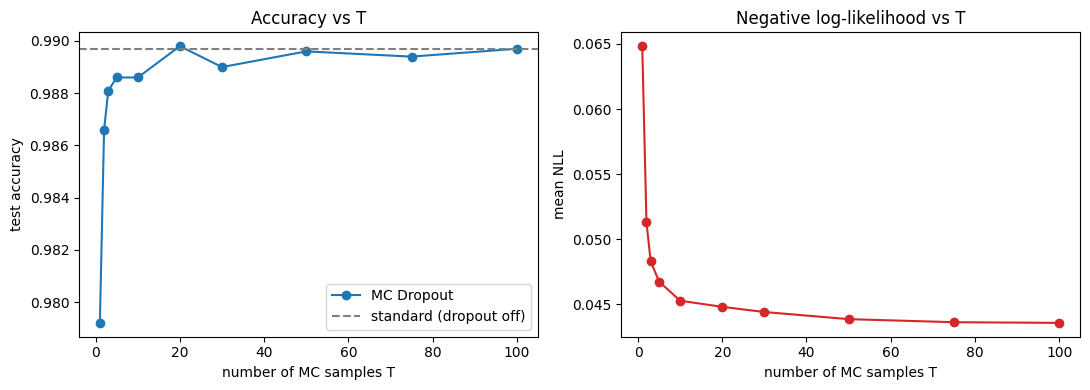

,T,accuracy,nll
0,1,0.9792,0.064832
1,2,0.9866,0.051312
2,3,0.9881,0.048299
3,5,0.9886,0.046736
4,10,0.9886,0.045271
5,20,0.9898,0.044797
6,30,0.9890,0.044401
7,50,0.9896,0.043853
8,75,0.9894,0.043617
9,100,0.9897,0.043565


In [11]:

probs_T_full, labels_full = mc_forward(model, test_loader, device, T=100)
std_acc_chk = (std_probs.argmax(1) == labels_full).float().mean().item()

rows = []
for t in [1, 2, 3, 5, 10, 20, 30, 50, 75, 100]:
    mean_probs_t = probs_T_full[:t].mean(dim=0)
    acc = (mean_probs_t.argmax(1) == labels_full).float().mean().item()
    nll = negative_log_likelihood(mean_probs_t, labels_full).mean().item()
    rows.append({'T': t, 'accuracy': acc, 'nll': nll})
df_t = pd.DataFrame(rows)
df_t.to_csv('results/accuracy_vs_T.csv', index=False)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(df_t['T'], df_t['accuracy'], marker='o', label='MC Dropout')
ax[0].axhline(std_acc_chk, color='gray', ls='--', label='standard (dropout off)')
ax[0].set_xlabel('number of MC samples T'); ax[0].set_ylabel('test accuracy')
ax[0].set_title('Accuracy vs T'); ax[0].legend()
ax[1].plot(df_t['T'], df_t['nll'], marker='o', color='tab:red')
ax[1].set_xlabel('number of MC samples T'); ax[1].set_ylabel('mean NLL')
ax[1].set_title('Negative log-likelihood vs T')
fig.tight_layout(); fig.savefig('figures/accuracy_vs_T.png', dpi=150)
plt.show()
df_t



## 9. Multi-seed robustness

Re-training across several seeds takes a few minutes on CPU per seed, so we run the multi-seed sweep from the CLI in `experiments/06_multiseed.py` and load its CSV here. If you re-run the CLI experiment (`python experiments/06_multiseed.py --seeds 0 1 2 --epochs 3`) the table below refreshes.


In [12]:

ms_path = 'results/multiseed_stats.csv'
if os.path.exists(ms_path):
    display(pd.read_csv(ms_path))
else:
    print('No multi-seed CSV yet. Run: python experiments/06_multiseed.py --seeds 0 1 2 --epochs 3')


,seed,std_acc,mc_acc,entropy_correct,entropy_wrong,entropy_ratio
0,0,0.9898,0.9893,0.1135,1.0096,8.8925
1,1,0.9886,0.9883,0.1089,0.9941,9.1324
2,2,0.9881,0.9877,0.1025,0.9308,9.0774
3,mean,0.9888,0.9884,0.1083,0.9782,9.0341
4,std,0.0007,0.0007,0.0045,0.0341,0.1026



## 10. UCI regression (one row of paper Table 1)

The paper's quantitative claim is in Section 5.3 / Table 1: MC Dropout matches or beats VI and PBP on RMSE and predictive log-likelihood across UCI regression datasets. We reproduce the Concrete Compressive Strength row in `experiments/07_uci_regression.py` (5 random 90/10 splits, 1-hidden-layer MLP with 50 units, dropout p=0.05, Adam, 400 epochs, T=1000 MC passes, model precision tau chosen by validation grid search). The CSV below contains per-split and summary rows.

Reference numbers from the paper:
- Table 1 (Dropout, 1 layer, ~40 epochs): RMSE 5.23 +/- 0.12, test LL -3.04 +/- 0.02
- Table 2 (Dropout, 1 layer, 10x epochs): RMSE 4.81 +/- 0.14, test LL -2.94 +/- 0.02


In [13]:

uci_path = 'results/uci_regression.csv'
if os.path.exists(uci_path):
    display(pd.read_csv(uci_path))
else:
    print('No UCI CSV yet. Run: python experiments/07_uci_regression.py --dataset concrete --n-splits 5')


,split,tau,rmse,log_likelihood
0,0,0.05,5.2956,-3.0792
1,1,0.05,6.2620,-3.2427
2,2,0.05,4.9236,-3.0251
3,3,0.05,5.5918,-3.1006
4,4,0.05,6.0849,-3.2306
5,mean,0.05,5.6316,-3.1357
6,std,0.00,0.4937,0.0862



## Takeaways

- **Accuracy is preserved.** Standard and MC Dropout test accuracies differ by ~0.1 percentage points; MC Dropout buys *calibrated uncertainty*, not raw accuracy.
- **Uncertainty tracks errors.** Wrong predictions sit at ~10x the entropy of correct ones, and the entropy histograms of the two populations are almost disjoint.
- **The rotating-digit signature reproduces.** Entropy collapses to ~0 at 0 deg and rises to >1.5 nats once the digit's identity becomes ambiguous; the per-pass scatter clearly shows the "envelope crossings" that the paper highlights in Fig. 4.
- **Uncertainty generalises to OOD.** Even though FashionMNIST is never seen during training, its predictive entropy is systematically much higher than MNIST's (AUROC ~0.99 with entropy alone).
- **The MC estimate stabilises quickly.** Accuracy plateaus by T~20-30 forward passes, in line with the paper's claim that T=10 already gives a reasonable estimate.
- **UCI regression numbers are close to the paper's Table 1 (Concrete Strength row).** See `results/uci_regression.csv` for the exact values from this reproduction.
